# Cologne8 Spatiotemporal Dependency

Use this notebook to generate presentation-ready evidence that traffic states in Cologne8 both persist over time and propagate across connected traffic signals.

The workflow follows the thesis recommendation directly:

1. Run one real Cologne8 rollout from an existing baseline controller.
2. Build one time series per TLS from aggregate incoming-lane density or queue.
3. Plot temporal autocorrelation for one representative signal.
4. Plot lagged cross-correlation for one representative 1-hop upstream-downstream pair.
5. Plot network-wide maximum lagged correlation by graph distance to show that dependency follows topology.

## Recommended Slide Story

- Main metric: aggregate incoming-lane density.
- Primary evidence: the two-panel temporal plus spatial-temporal figure.
- Stronger backup evidence: boxplot of maximum lagged correlation grouped by graph distance.
- Secondary analysis: switch `SIGNAL_METRIC` to `"queue"` if you want congestion propagation instead of density propagation.

In [1]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "sumo_rl").exists() and (candidate / "pyproject.toml").exists():
            return candidate
    raise RuntimeError("Could not locate the repo root from the current working directory.")


REPO_ROOT = find_repo_root()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

try:
    from experiments.spatiotemporal_dependency import (
        DEFAULT_ARTIFACT_DIR,
        ROOT,
        analyze_spatiotemporal_dependency,
        collect_signal_trace,
        export_dependency_artifacts,
        load_scenario_cfg,
        plot_dependency_panels,
        plot_distance_boxplot,
        plot_pairwise_heatmap,
    )
except ModuleNotFoundError:
    module_path = REPO_ROOT / "experiments" / "spatiotemporal_dependency.py"
    spec = importlib.util.spec_from_file_location("experiments.spatiotemporal_dependency", module_path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Could not load helper module from {module_path}")
    dependency_module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = dependency_module
    spec.loader.exec_module(dependency_module)
    DEFAULT_ARTIFACT_DIR = dependency_module.DEFAULT_ARTIFACT_DIR
    ROOT = dependency_module.ROOT
    analyze_spatiotemporal_dependency = dependency_module.analyze_spatiotemporal_dependency
    collect_signal_trace = dependency_module.collect_signal_trace
    export_dependency_artifacts = dependency_module.export_dependency_artifacts
    load_scenario_cfg = dependency_module.load_scenario_cfg
    plot_dependency_panels = dependency_module.plot_dependency_panels
    plot_distance_boxplot = dependency_module.plot_distance_boxplot
    plot_pairwise_heatmap = dependency_module.plot_pairwise_heatmap


plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.grid"] = False
pd.set_option("display.max_colwidth", 120)

print(f"Repo root: {ROOT}")

c:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-07-06 16:53:13,930	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.
2026-07-06 16:53:16,488	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Repo root: C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl


In [2]:
SCENARIO_NAME = "resco_cologne8"
CONTROLLER = "fixed_time"  # "fixed_time" or "static_max_pressure"
SIGNAL_METRIC = "density"  # "density" or "queue"
AGGREGATION = "mean"  # "mean" keeps signals comparable across different lane counts
SEED = 1
EPISODE_SECONDS = 3600  # use 600 for a quick smoke run
MAX_LAG_SECONDS = 60
DISTANCE_MODE = "directed"  # directed matches upstream-downstream propagation better
USE_LIBSUMO = False
SAVE_ARTIFACTS = False
ARTIFACT_DIR = DEFAULT_ARTIFACT_DIR / SCENARIO_NAME

SCENARIO_NAME, CONTROLLER, SIGNAL_METRIC, EPISODE_SECONDS

('resco_cologne8', 'fixed_time', 'density', 3600)

In [3]:
cfg = load_scenario_cfg(
    scenario_name=SCENARIO_NAME,
    controller=CONTROLLER,
    episode_seconds=EPISODE_SECONDS,
    seed=SEED,
)
trace_bundle = collect_signal_trace(
    cfg=cfg,
    controller=CONTROLLER,
    seed=SEED,
    use_libsumo=USE_LIBSUMO,
    aggregation=AGGREGATION,
)
analysis_bundle = analyze_spatiotemporal_dependency(
    trace_bundle,
    signal_metric=SIGNAL_METRIC,
    aggregation=AGGREGATION,
    max_lag_seconds=MAX_LAG_SECONDS,
    distance_mode=DISTANCE_MODE,
)

print(f"Scenario: {trace_bundle['scenario_name']}")
print(f"Controller: {trace_bundle['controller']}")
print(f"Decision interval: {trace_bundle['decision_seconds']} s")
print(f"Snapshots per signal: {analysis_bundle['pivot_df'].shape[0]}")
print(f"Signals: {analysis_bundle['pivot_df'].shape[1]}")
print(f"Metric: {analysis_bundle['value_label']}")
print(f"Representative signal: {analysis_bundle['representative_signal_id']}")
print(f"Representative pair: {analysis_bundle['representative_pair'][0]} -> {analysis_bundle['representative_pair'][1]}")
print(f"Actual max lag plotted: {analysis_bundle['max_lag_seconds']} s")

Scenario: resco_cologne8
Controller: fixed_time
Decision interval: 5 s
Snapshots per signal: 721
Signals: 8
Metric: mean incoming-lane density
Representative signal: 62426694
Representative pair: 62426694 -> 280120513
Actual max lag plotted: 60 s


In [4]:
selected_pair_df = analysis_bundle["pair_metrics_df"].loc[
    lambda df: (df["source_id"] == analysis_bundle["representative_pair"][0])
    & (df["target_id"] == analysis_bundle["representative_pair"][1])
].copy()

distance_summary_df = (
    analysis_bundle["pair_metrics_df"]
    .groupby("distance_category", dropna=False)
    .agg(
        pair_count=("max_corr", "size"),
        mean_max_corr=("max_corr", "mean"),
        median_max_corr=("max_corr", "median"),
        mean_max_positive_lag_corr=("max_positive_lag_corr", "mean"),
    )
    .reindex(["1-hop", "2-hop", "Distant"])
    .reset_index()
)

display(selected_pair_df)
display(distance_summary_df)

,source_id,target_id,distance_mode,graph_distance,distance_category,max_corr,best_lag_step,best_lag_seconds,max_positive_lag_corr,best_positive_lag_step,best_positive_lag_seconds
10,62426694,280120513,directed,1.0,1-hop,0.459353,8.0,40.0,0.459353,8.0,40.0


,distance_category,pair_count,mean_max_corr,median_max_corr,mean_max_positive_lag_corr
0,1-hop,13,0.223063,0.247028,0.220991
1,2-hop,12,0.119719,0.108998,0.114190
2,Distant,31,0.043755,0.010296,0.033809


## Presentation Figure

The left panel shows where the selected TLS pair sits inside the Cologne8 graph. The middle and right panels are the exact temporal and spatial-temporal dependency plots that fit naturally on a defense slide.

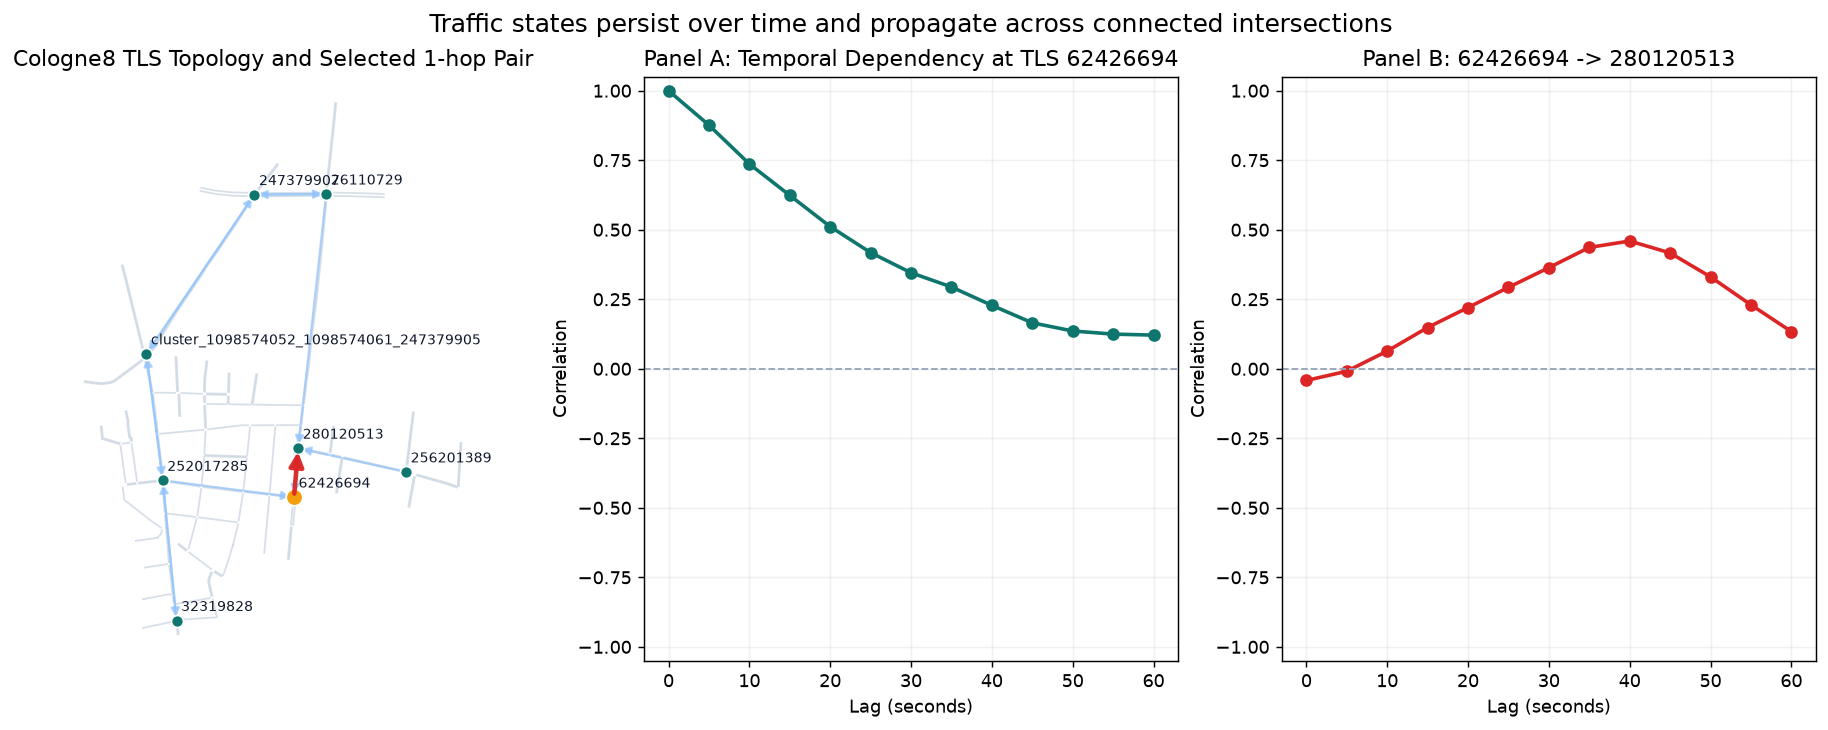

In [5]:
panel_figure, panel_axes = plot_dependency_panels(trace_bundle, analysis_bundle)
panel_figure.suptitle(
    "Traffic states persist over time and propagate across connected intersections",
    fontsize=14,
)
plt.show()

## Network-Wide Evidence

Because Cologne8 is small, you can also show the full network-wide pattern. The boxplot is the strongest backup plot for justifying graph-based encoding, and the heatmap helps you inspect which ordered pairs carry the strongest lagged dependency.

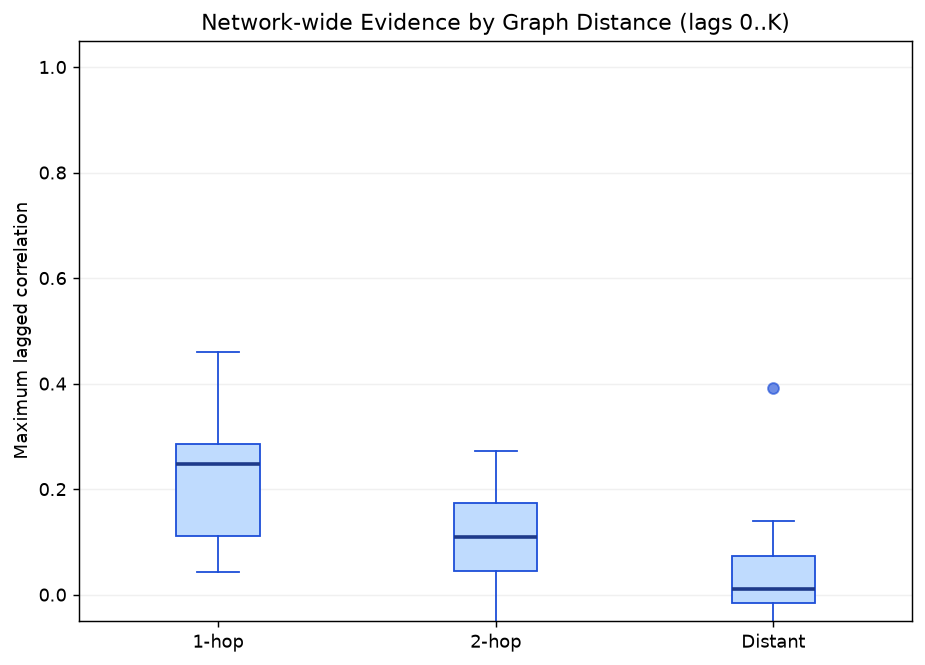

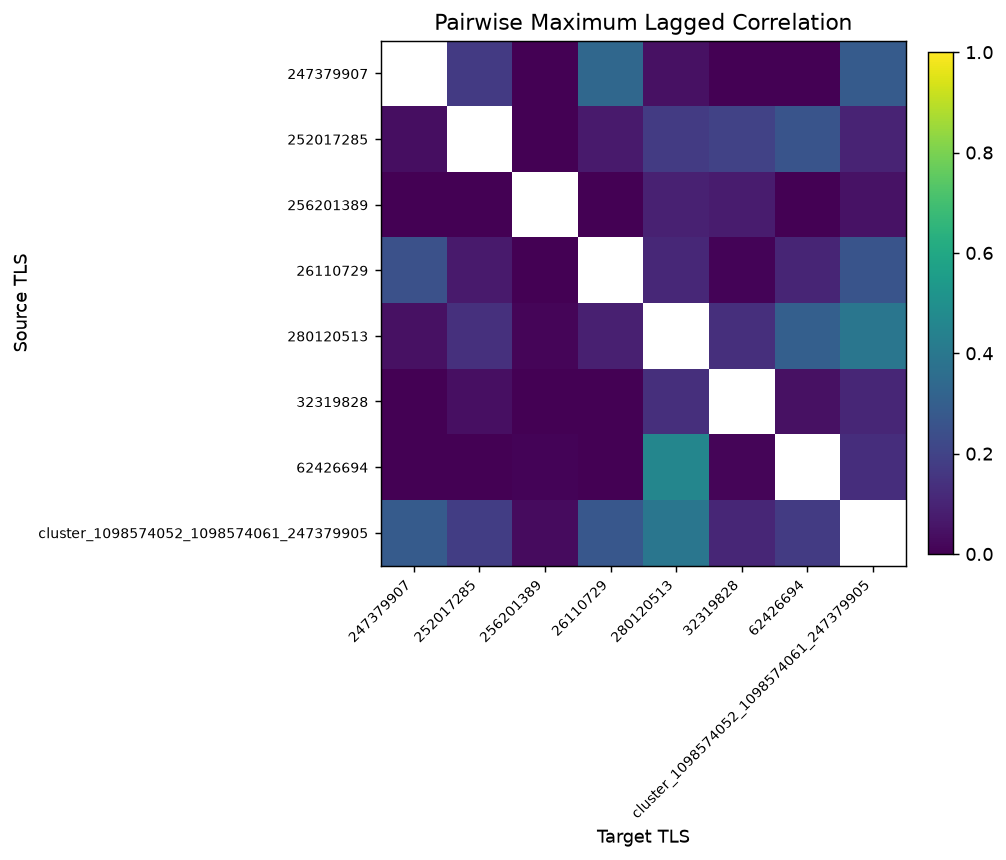

In [6]:
boxplot_figure, boxplot_ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
plot_distance_boxplot(boxplot_ax, analysis_bundle)
plt.show()

heatmap_figure, heatmap_ax = plt.subplots(figsize=(7.5, 6.5), constrained_layout=True)
plot_pairwise_heatmap(heatmap_ax, analysis_bundle)
plt.show()

In [ ]:
if SAVE_ARTIFACTS:
    artifact_paths = export_dependency_artifacts(
        trace_bundle,
        analysis_bundle,
        output_dir=Path(ARTIFACT_DIR),
    )
    display(pd.DataFrame({"artifact": list(artifact_paths.keys()), "path": [str(path) for path in artifact_paths.values()]}))
else:
    print("Artifact export skipped. Set SAVE_ARTIFACTS = True to write CSV and PNG outputs.")

,artifact,path
0,trace_csv,C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\experiments\artifacts\spatiotemporal_dependency\resco_...
1,pair_csv,C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\experiments\artifacts\spatiotemporal_dependency\resco_...
2,autocorr_csv,C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\experiments\artifacts\spatiotemporal_dependency\resco_...
3,crosscorr_csv,C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\experiments\artifacts\spatiotemporal_dependency\resco_...
4,panels_png,C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\experiments\artifacts\spatiotemporal_dependency\resco_...
5,boxplot_png,C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\experiments\artifacts\spatiotemporal_dependency\resco_...
6,heatmap_png,C:\Users\PC\Desktop\Bai_lam_Nhat_Minh\VGU\Thesis\Code\sumo-rl\experiments\artifacts\spatiotemporal_dependency\resco_...
